# EDA — Synthetic Polaris Support Tickets (v1)

Exploratory analysis of the **generated** dataset (`data/tickets.jsonl`) — 2,038 synthetic support tickets for the fictional analytics SaaS *Polaris*, spanning calendar year 2024.

The pipeline that produced it: scenario catalog → reproducible sampler → LLM (Gemini 2.5-flash-lite via Vertex) → assembled + re-dated locally.

This notebook validates the dataset and doubles as the basis for the Hugging Face dataset card.

## 1. Load & overview

In [1]:
import os, sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make the repo root importable + find the data whether we run from root or notebooks/
for p in ('.', '..'):
    if os.path.isdir(os.path.join(p, 'src')):
        sys.path.insert(0, os.path.abspath(p)); ROOT = p; break
DATA = os.path.join(ROOT, 'data', 'tickets.jsonl')

sns.set_theme(style='whitegrid')
df = pd.read_json(DATA, lines=True)
print('shape:', df.shape)
df.head(3)

Matplotlib is building the font cache; this may take a moment.


shape: (2038, 15)


,ticket_id,created_at,channel,plan,user_role,reported_category,topic,type,priority,routing,sentiment,event_id,event_type,subject,body
0,TCK-000001,2024-01-01 01:39:55,in_app,growth,admin,how_to_question,connectors,how_to,low,kb_autoresolve,neutral,NaN,NaN,,how do i re-authorize my google ads connector?...
1,TCK-000002,2024-01-01 02:10:27,email,starter,viewer,users_access,alerts,feature_request,low,engineering,neutral,NaN,NaN,alert delivery to slack?,"hi, i was wondering if there's a way to get ou..."
2,TCK-000003,2024-01-01 09:57:46,email,growth,admin,users_access,users_workspace,misconfiguration,medium,kb_autoresolve,confused,NaN,NaN,quick question about roles,"hi, my teammate said they can't see the google..."


In [2]:
# dtypes + nulls (event_id/event_type are null BY DESIGN — reserved for the v2 event layer)
print(df.dtypes)
print('\nnulls:')
print(df.isnull().sum())

ticket_id                       str
created_at           datetime64[us]
channel                         str
plan                            str
user_role                       str
reported_category               str
topic                           str
type                            str
priority                        str
routing                         str
sentiment                       str
event_id                    float64
event_type                  float64
subject                         str
body                            str
dtype: object

nulls:
ticket_id               0
created_at              0
channel                 0
plan                    0
user_role               0
reported_category       0
topic                   0
type                    0
priority                0
routing                 0
sentiment               0
event_id             2038
event_type           2038
subject                 0
body                    0
dtype: int64


## 2. Target label distributions

The five ground-truth labels the triage model must predict: `topic · type · priority · routing · sentiment`.

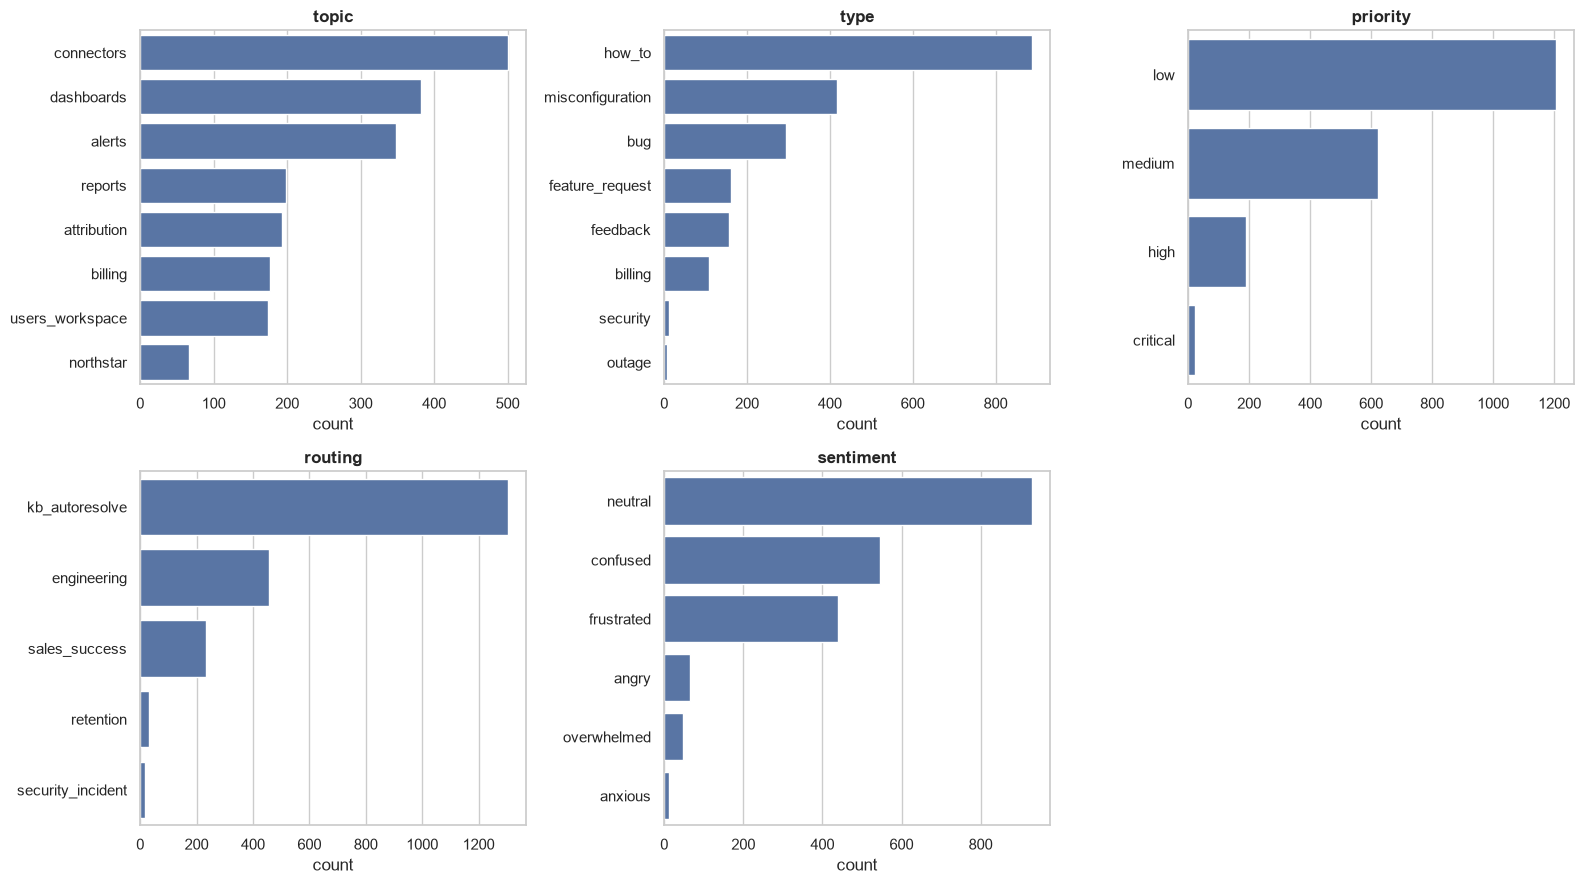

In [3]:
targets = ['topic', 'type', 'priority', 'routing', 'sentiment']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, targets):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, color='#4C72B0')
    ax.set_title(col, fontweight='bold'); ax.set_xlabel('count'); ax.set_ylabel('')
axes.flat[-1].axis('off')
plt.tight_layout(); plt.show()

In [4]:
# priority as shares — should track the ~60/30/9/1 design target
(df['priority'].value_counts(normalize=True).mul(100).round(1)
   .reindex(['low','medium','high','critical']))

priority
low         59.1
medium      30.6
high         9.3
critical     1.0
Name: proportion, dtype: float64

**Read:** priority lands near the intended **60 / 30 / 9 / 1** mix, and `kb_autoresolve` is the largest routing bucket — the RAG-deflection story the demo is built to show. Sentiment skews neutral→negative (realistic for inbound support; nobody opens a ticket to say thanks).

## 3. Label coherence (cross-tabs)

Labels are sampled from a scenario catalog, not as independent dice — so combinations stay realistic (no `low`-priority `outage`). The cross-tabs show only *valid* pairs are populated.

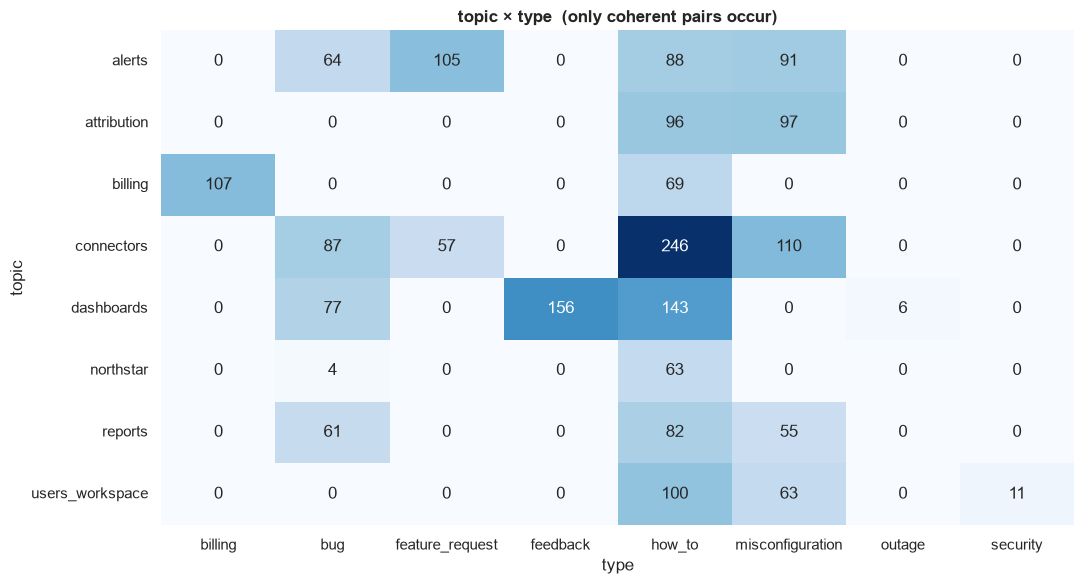

In [5]:
ct = pd.crosstab(df['topic'], df['type'])
plt.figure(figsize=(11, 6))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('topic × type  (only coherent pairs occur)', fontweight='bold')
plt.tight_layout(); plt.show()

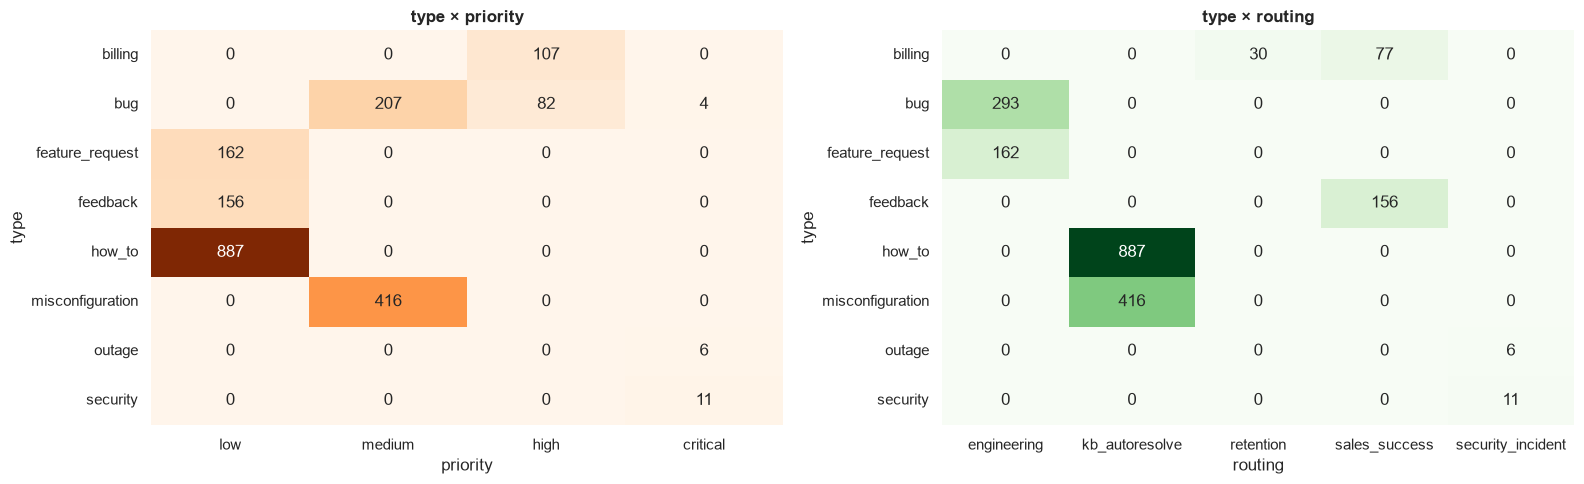

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(pd.crosstab(df['type'], df['priority'])[['low','medium','high','critical']],
            annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[0])
axes[0].set_title('type × priority', fontweight='bold')
sns.heatmap(pd.crosstab(df['type'], df['routing']), annot=True, fmt='d',
            cmap='Greens', cbar=False, ax=axes[1])
axes[1].set_title('type × routing', fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Intake noise — `reported_category`

`reported_category` is the customer's own picklist choice at submission, **deliberately noisy**: users mis-tag their tickets. This is the headroom the triage model gets to *correct* — a real value story, not just noise.

intake mismatch vs true label: 35.0%


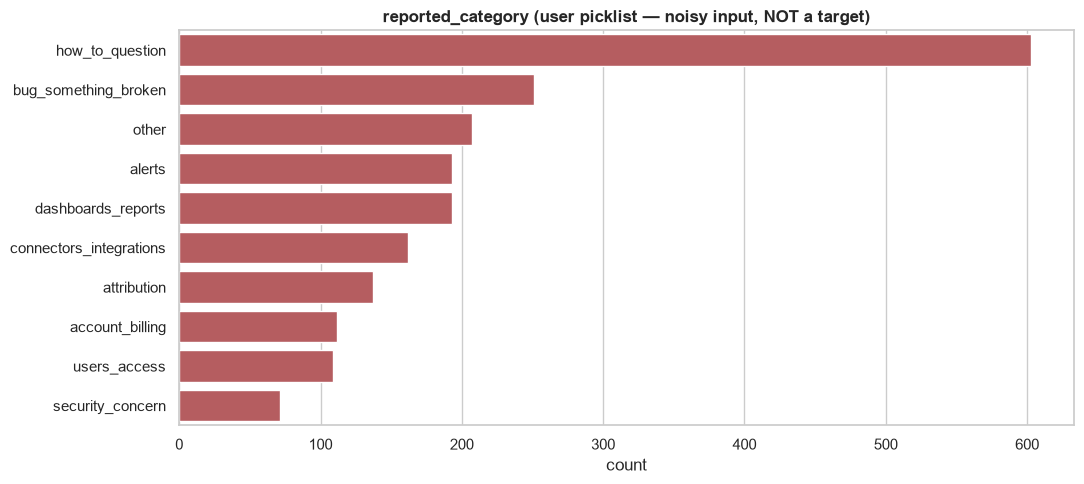

In [7]:
from src.sampler import aligned_category
df['aligned_category'] = [aligned_category(t, y) for t, y in zip(df['topic'], df['type'])]
mismatch = (df['reported_category'] != df['aligned_category']).mean()
print(f'intake mismatch vs true label: {mismatch:.1%}')

plt.figure(figsize=(11, 5))
sns.countplot(data=df, y='reported_category',
              order=df['reported_category'].value_counts().index, color='#C44E52')
plt.title('reported_category (user picklist — noisy input, NOT a target)', fontweight='bold')
plt.xlabel('count'); plt.ylabel(''); plt.tight_layout(); plt.show()

## 5. Text analysis

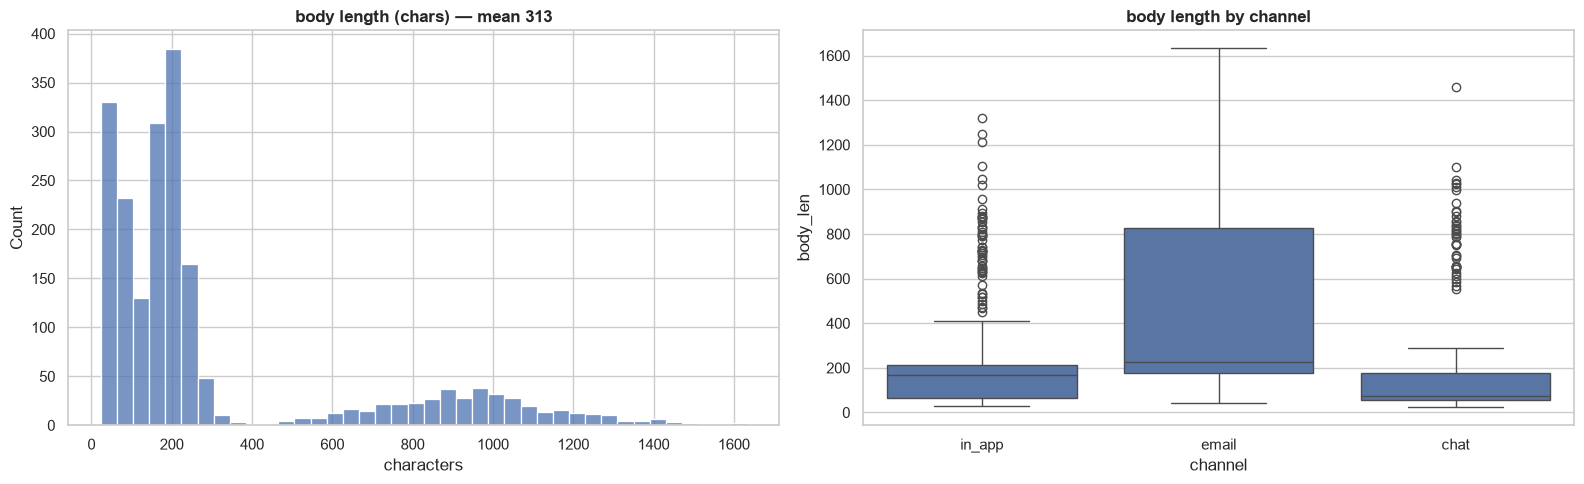

empty-subject rate by channel:
channel
chat      100.0
email       0.0
in_app     68.2
Name: empty, dtype: float64


In [8]:
df['body_len'] = df['body'].str.len()
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df['body_len'], bins=40, ax=axes[0], color='#4C72B0')
axes[0].set_title(f"body length (chars) — mean {df['body_len'].mean():.0f}", fontweight='bold')
axes[0].set_xlabel('characters')
sns.boxplot(data=df, x='channel', y='body_len', ax=axes[1])
axes[1].set_title('body length by channel', fontweight='bold')
plt.tight_layout(); plt.show()

empty_subj = df.assign(empty=df['subject'].str.len().eq(0)).groupby('channel')['empty'].mean()
print('empty-subject rate by channel:'); print((empty_subj*100).round(1))

In [9]:
# a few sample tickets across priorities
for prio in ['low', 'high', 'critical']:
    r = df[df['priority'] == prio].iloc[0]
    print(f"[{prio}] {r['topic']}/{r['type']} · {r['channel']} · {r['sentiment']}")
    print(f"  subject: {r['subject']!r}")
    print(f"  body: {r['body'][:200]}")
    print()

[low] connectors/how_to · in_app · neutral
  subject: ''
  body: how do i re-authorize my google ads connector? it expired

[high] dashboards/bug · chat · frustrated
  subject: ''
  body: this dashboard numbers are all messed up, need it fixed asap

[critical] users_workspace/security · email · anxious
  subject: 'URGENT: Seeing wrong data in my workspace!'
  body: Hi, I think there's a really serious problem. I'm seeing data in my Polaris dashboard that looks like it belongs to another company, not mine. This is making it impossible to do my work and I'm really



## 6. Temporal distribution (2024)

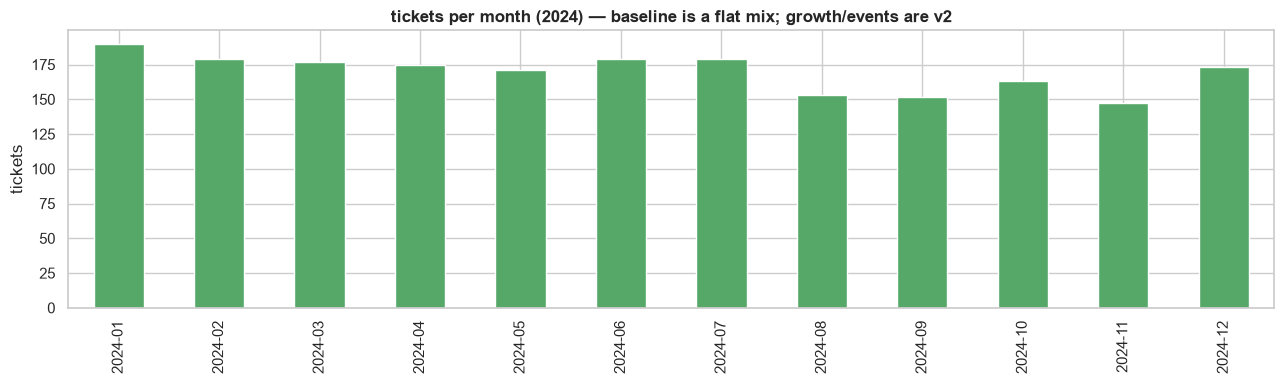

In [10]:
df['month'] = pd.to_datetime(df['created_at']).dt.to_period('M').astype(str)
plt.figure(figsize=(13, 4))
df['month'].value_counts().sort_index().plot(kind='bar', color='#55A868')
plt.title('tickets per month (2024) — baseline is a flat mix; growth/events are v2',
          fontweight='bold')
plt.ylabel('tickets'); plt.xlabel(''); plt.tight_layout(); plt.show()

## 7. Operational metadata

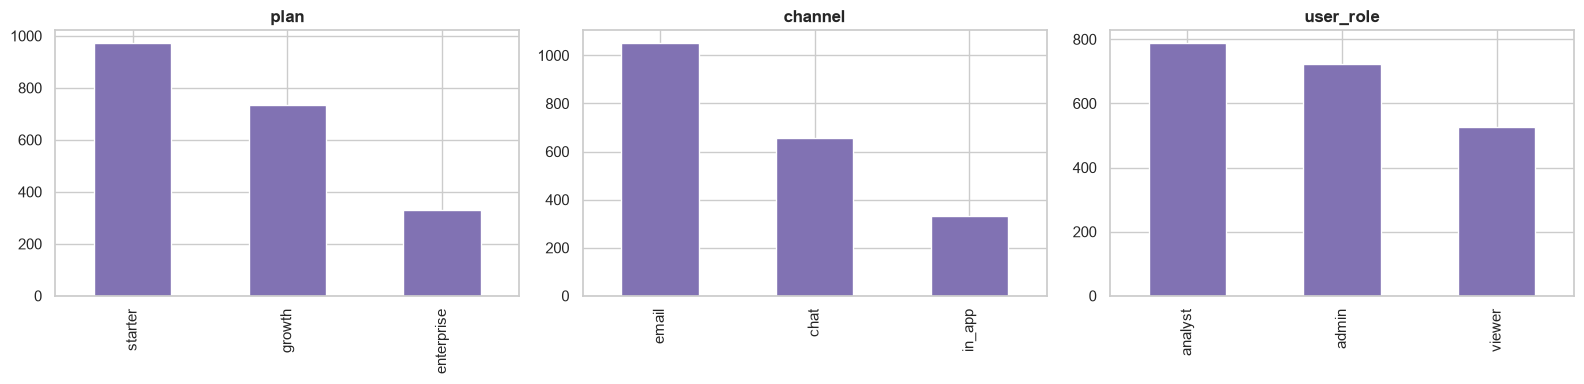

In [11]:
meta = ['plan', 'channel', 'user_role']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, meta):
    df[col].value_counts().plot(kind='bar', ax=ax, color='#8172B3')
    ax.set_title(col, fontweight='bold'); ax.set_xlabel('')
plt.tight_layout(); plt.show()

## Takeaways

- **2,038 tickets**, 15 fields, clean (only the reserved `event_*` are null).
- Label distributions match the design: priority ≈ 60/30/9/1, `kb_autoresolve` dominant (deflection story).
- Combinations are **coherent by construction** (scenario catalog), not random.
- ~35% **intake mismatch** = the model's opportunity to correct user mis-tagging.
- Text is realistic (varied length by channel, empty subjects on chat).

This dataset is the ground truth for the triage classifier and the retrieval corpus for the RAG demo. Next: publish to Hugging Face + build the RAG core.